## Exploratory Data Analysis (EDA)

This notebook completes exploratory data analysis of the data used in this project. It includes analysis of the raw data and analysis of the feature-engineered data that is used in modeling.

In [8]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "../")

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda

config = VersionConfig.load().build()
run = PipelineRun(config)
stages = PipelineFactory.retrain_existing_data(config)

VersionConfig loaded:
  data:          v3.4 (raw_suffix='real')
  baselines:     v4.0
  model:         v5.1
  hyperparams:   v1.1
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.4 (unchanged)
  baselines         : v4.0 (unchanged)
  model             : v5.1 (unchanged)
  hyperparams       : v1.1 (unchanged)
  raw_version       : v3.4_real
  next_final_version: v3.4_100real
  model_version     : v5.1
  baselines_version : v4.0
  hyperparam_version: v1.1
  use_synthetic     : False


### Pipeline Execution

Runs the pipeline through `Scaler` — the minimum set of stages needed to produce both `df_clean` (for pre-processing analysis) and `df_engineered` (for post-feature-engineering analysis), as well as the scaled train/test/val splits.

No model training or snapshotting occurs in this notebook. Stage outputs are read from the GCS parquet snapshot at the version pinned in `config/versions.json`.

In [9]:
stages.loader.run(run)
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)

run.summary()

Loaded snapshot 'v3.4_real': 60696 rows from 2026-04-29
  Polls: {'upload': 21398, '24h': 20906, '7d': 18392}
Loaded baselines 'v4.0': 28814 baseline videos, 974 median rows (974 channels)
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 18334 (dropped 3111 incomplete)
  Pivoted shape: (18403, 34)

[2/3] Joining baseline medians...
  Baseline join: 18403/18403 videos matched a channel median

[3/3] Cleaning data...
  Cleaned: 18403 rows × 40 columns

Clean dataset: 18403 rows × 40 columns
  all: dropped 414 rows with NaN in a ba

---
## Part 1 — Pre-Processing Analysis

`df_clean` is the output of `DataPreprocessor`, which chains three transformations on the raw per-video snapshot rows loaded from GCS:

1. **`pivot_snapshots`** — The raw data has one row per video per poll label (`upload`, `24h`, `7d`). This step pivots to a single wide row per video, creating columns like `view_count_upload`, `view_count_24h`, `view_count_7d`. Any video that does not have all three labels is dropped — partial triplets cannot be used because the growth-rate features computed downstream require all three time points.

2. **`join_baselines`** — Attaches per-channel median engagement metrics from `df_medians`. These baseline columns (e.g., `baseline_median_view_count_7d`) are later used by `FeatureEngineer` to compute the `above_baseline` target: whether a given video outperformed its channel's own historical median.

3. **`clean_data`** — Structural cleanup: type coercion, column renames, and removal of any rows with structural nulls introduced by the pivot or join.

The result is one row per complete-triplet video, containing raw engagement counts, channel-level baselines, and categorical metadata (`vertical`, `tier`).

In [10]:
eda.set_active_df(run, run.df_clean)

df = run.active_eda_df
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nDtype breakdown:")
print(df.dtypes.value_counts().to_string())
df.describe()

Shape: 18,403 rows x 40 columns

Dtype breakdown:
Int64                  18
object                 11
float64                 6
datetime64[us, UTC]     4
boolean                 1


,duration_seconds,face_count,brightness,colorfulness,view_count_upload,like_count_upload,comment_count_upload,subscriber_count_upload,hours_since_publish_upload,view_count_24h,...,view_count_7d,like_count_7d,comment_count_7d,subscriber_count_7d,hours_since_publish_7d,baseline_baseline_video_count,baseline_median_views,baseline_median_likes,baseline_median_comments,baseline_median_engagement_rate
count,18403.0,18403.0,18403.000000,18403.000000,18403.0,18403.0,18403.0,18403.0,18403.000000,18403.0,...,18403.0,18403.0,18403.0,18403.0,18403.000000,18403.0,18403.0,18403.0,18403.0,18403.000000
mean,964.527305,0.838179,77.237321,42.495049,6313.721839,367.114112,24.568005,1518290.164104,3.417058,44165.88779,...,111925.871488,2684.74678,113.021355,1521897.776449,156.192691,29.012607,62110.855784,2070.65924,80.703635,0.037355
std,2610.353235,0.986048,28.791995,23.629676,35374.164682,1485.063997,100.272483,2359561.632236,51.967447,314400.405311,...,1153942.465686,13474.524173,454.58912,2365144.573324,7.559868,3.301904,235762.914121,7555.097877,225.910913,0.026640
min,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1010.0,-0.020000,0.0,...,0.0,0.0,0.0,1020.0,0.890000,7.0,11.0,0.0,0.0,0.000000
25%,43.0,0.0,58.737526,25.004793,59.0,4.0,0.0,39600.0,0.960000,652.0,...,1117.5,25.0,1.0,39700.0,156.340000,30.0,1199.0,28.0,1.0,0.018715
50%,158.0,1.0,74.957726,37.247885,419.0,24.0,1.0,298000.0,2.050000,3013.0,...,5857.0,185.0,8.0,299000.0,157.080000,30.0,5975.0,186.0,7.0,0.030340
75%,972.0,1.0,93.063304,56.356811,1867.5,146.0,8.0,1830000.0,3.350000,13932.0,...,31101.5,975.0,50.0,1840000.0,158.070000,30.0,29230.0,871.0,47.0,0.051282
max,86134.0,14.0,214.873264,170.229322,1650228.0,52463.0,4587.0,10000000.0,4948.330000,26047103.0,...,105938940.0,650419.0,15102.0,10000000.0,275.000000,30.0,4589046.0,135730.0,5977.0,0.200666


### Data Quality — Missing Values & Duplicates

This project does not use imputation. Incomplete records are addressed structurally at the pipeline stage that introduces the gap:

- **Missing triplets** — dropped by `pivot_snapshots` before any modeling data is produced. A video with only an `upload` snapshot and no `24h` or `7d` observation cannot contribute growth-rate features and is excluded entirely.
- **Missing baselines** — a video whose channel has no historical median in `df_medians` would produce a null `above_baseline` target and is also excluded by the join.

The cells below confirm that `df_clean` contains no residual nulls after these upstream exclusions, and that `video_id` is unique (no duplicate rows from repeated snapshot pulls).

In [11]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
quality = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
quality = quality[quality["null_count"] > 0]

if quality.empty:
    print("No missing values detected in df_clean.")
else:
    print(f"Columns with nulls ({len(quality)}):")
    display(quality.sort_values("null_count", ascending=False))

Columns with nulls (1):


,null_count,null_pct
contains_synthetic_media,15,0.08


In [12]:
n_dup = df.duplicated(subset="video_id").sum()
print(f"Total rows:          {len(df):,}")
print(f"Unique video_ids:    {df['video_id'].nunique():,}")
print(f"Duplicate video_ids: {n_dup}")

Total rows:          18,403
Unique video_ids:    18,334
Duplicate video_ids: 69


### Outlier Analysis

Engagement metrics follow a power-law distribution: a small number of videos receive disproportionately large view counts (viral events), while the majority cluster at lower values. Standard IQR-based fences (Q1 − 1.5·IQR, Q3 + 1.5·IQR) are applied to each continuous feature to quantify how many rows fall outside the expected range.

**Decision: outliers are retained.** These are real observations, not data entry errors. Removing viral events would bias the dataset toward average-performing content and distort the channel-relative baseline comparison that defines the target variable. Downstream, the `FeatureEngineer` ratio and growth-rate features partially compress extreme raw counts, and the tree-based models (Random Forest, XGBoost) are robust to outliers in the feature space.

A high `pct_outliers` value on a raw count column (e.g., `view_count_7d`) is expected and does not signal a data quality problem.

In [13]:
exclude_ = {"video_id", "above_baseline", "is_short", "is_long"}
num_cols_ = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_]

rows_ = []
for col in num_cols_:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    rows_.append({
        "feature": col,
        "q1": round(q1, 3),
        "q3": round(q3, 3),
        "iqr": round(iqr, 3),
        "lower_fence": round(lo, 3),
        "upper_fence": round(hi, 3),
        "n_outliers": n_out,
        "pct_outliers": round(n_out / len(s) * 100, 2),
    })

pd.DataFrame(rows_).sort_values("pct_outliers", ascending=False).reset_index(drop=True)

,feature,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
0,comment_count_upload,0.000,8.000,8.000,-12.000,20.000,3016,16.39
1,baseline_median_likes,28.000,871.000,843.000,-1236.500,2135.500,3002,16.31
2,baseline_median_views,1199.000,29230.000,28031.000,-40847.500,71276.500,2915,15.84
3,like_count_7d,25.000,975.000,950.000,-1400.000,2400.000,2889,15.70
4,comment_count_7d,1.000,50.000,49.000,-72.500,123.500,2887,15.69
5,comment_count_24h,1.000,32.000,31.000,-45.500,78.500,2847,15.47
6,view_count_7d,1117.500,31101.500,29984.000,-43858.500,76077.500,2837,15.42
7,like_count_upload,4.000,146.000,142.000,-209.000,359.000,2825,15.35
8,like_count_24h,16.000,579.000,563.000,-828.500,1423.500,2810,15.27
9,view_count_upload,59.000,1867.500,1808.500,-2653.750,4580.250,2808,15.26


### Engagement Metric Distributions — All Features

Plain histograms (40 bins, no KDE curve) across all continuous features in `df_clean`. KDE is omitted from this full-grid view because computing kernel density for every feature on a large dataset is prohibitively slow — each `sns.histplot(kde=True)` call estimates the density at every data point.

What to look for:
- **Right skew** — expected for raw view/like/comment counts; the long right tail represents viral outliers retained from the outlier analysis above.
- **Bimodal or multi-modal shape** — may indicate subpopulations (e.g., Shorts vs. long-form videos mixed together before `is_short` filtering).
- **Near-zero-variance columns** — these will be filtered out by `FeatureEngineer` before modeling.

See the next cell for smoothed KDE curves on the most analytically important features.

NameError: name 'ext' is not defined

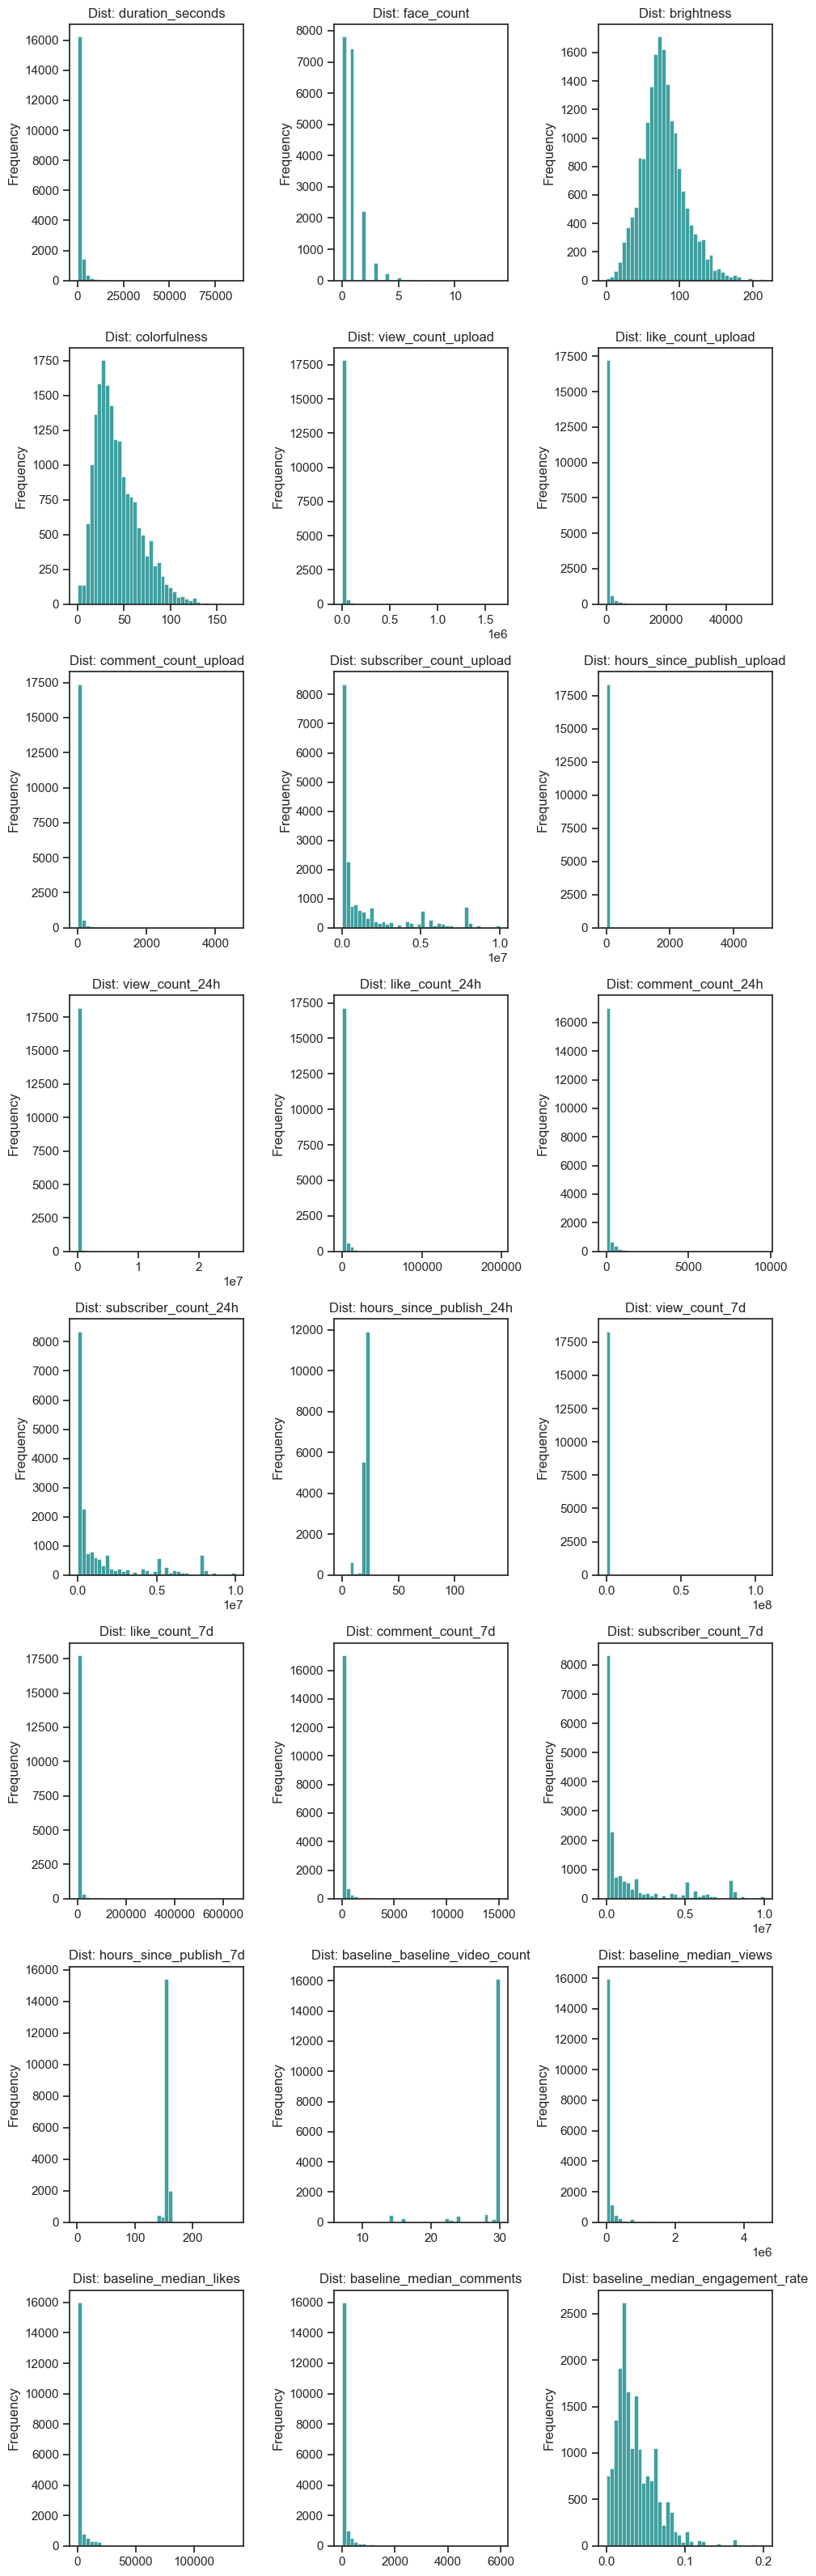

In [14]:
eda.plot_engagement_distribution(run, save_figure_name="01_engagement_distributions")

### Engagement Metric Distributions — Priority Features with KDE

Smoothed density curves for the core engagement signals. KDE is computed using `scipy.stats.gaussian_kde` on a 200-point grid — this is fast because the density function is evaluated at 200 fixed points rather than at every data point in the dataset.

These features are prioritised because they directly anchor the target definition:
- **`view_count_upload` / `view_count_24h` / `view_count_7d`** — the three snapshot-time raw counts whose ratio defines growth velocity.
- **`like_count_24h` / `comment_count_24h`** — secondary engagement signals that appear in the feature correlation analysis.

The orange curve is the KDE smoothing; the teal histogram shows the empirical count distribution normalised to density so both y-axes align.

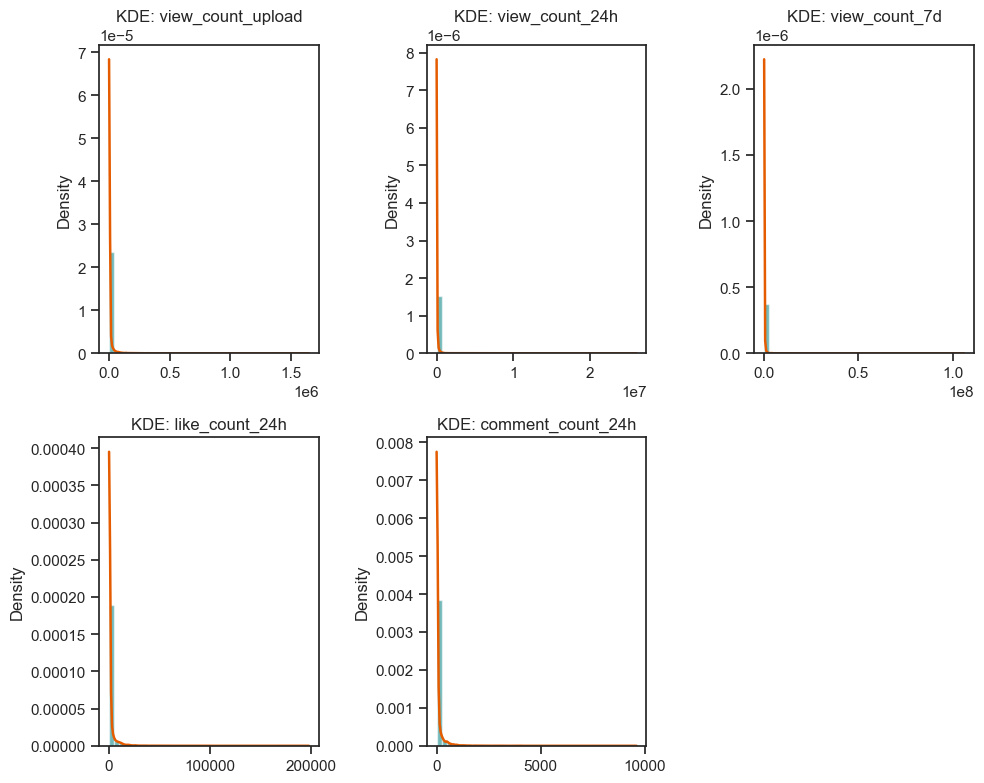

In [ ]:
eda.plot_kde_distributions(run, save_figure_name="02_engagement_kde_distributions")

### Vertical Segmentation — View Velocity

Distribution of `view_count_24h` across content verticals. The 24-hour count is chosen because it is the most predictive single signal of eventual 7-day performance and the primary time point used in the growth-rate features.

- **Left subplot (boxplot)** — shows median, IQR, and outlier positions per vertical. Medians at very different scales across verticals confirm that raw view counts are not comparable across content categories — the channel-relative baseline normalisation in `FeatureEngineer` is necessary.
- **Right subplot (density overlay)** — uses `scipy.stats.gaussian_kde` per vertical, evaluated at 200 points each (one fast KDE call per vertical rather than per data point). Overlapping filled curves show distributional shape and spread differences between verticals that the boxplot's summary statistics alone would obscure.

/Users/jelanigould-bailey/Desktop/uc_berkeley_capstone_repo/repo/src/capstone/notebooks/../pipeline/stages/eda.py:301: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="vertical", y=feature, palette="Set2", order=verticals_)


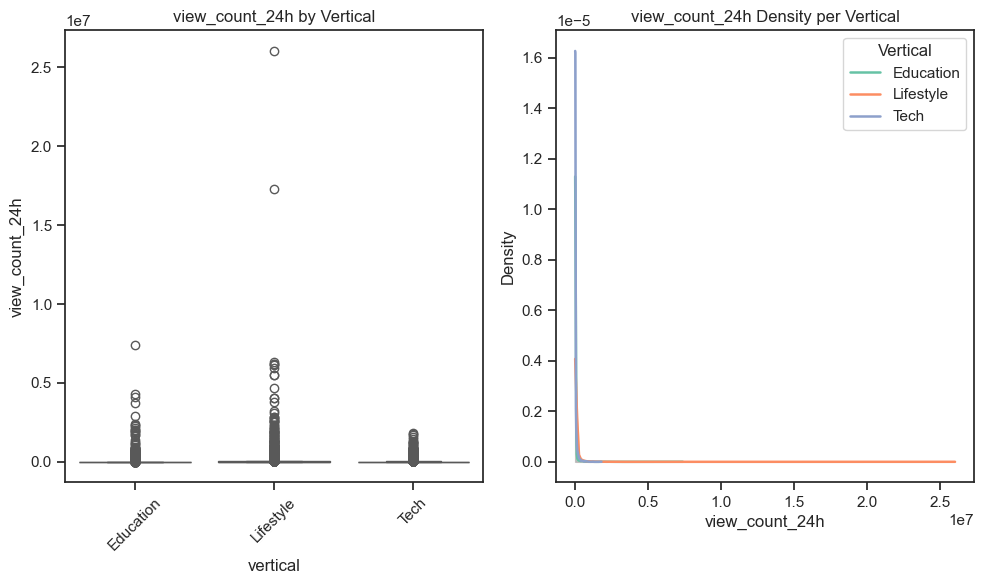

In [ ]:
eda.plot_vertical_segmentation(run, feature="view_count_24h", save_figure_name="03_view_velocity")

---
## Part 2 — Post-Feature Engineering Analysis

`df_engineered` is the output of `FeatureEngineer`, which runs `engineer_features` on `df_clean` and produces the final modeling-ready dataset. Key transformations:

1. **Target computation** — `above_baseline = 1` if `view_count_7d > baseline_median_view_count_7d`, else `0`. This is a per-channel relative metric: the same absolute view count can be above baseline for a small channel and below baseline for a large one. The expected overall rate is approximately 50% by construction.

2. **Ratio and growth-rate features** — e.g., `view_ratio_24h_upload` (24h views / upload-day views), `view_ratio_7d_24h` (7d / 24h). These compress the right-skewed raw counts into more Gaussian, scale-invariant signals and are the primary features for the linear model.

3. **Categorical encoding** — `vertical` and `tier` are ordinally or one-hot encoded. The original string columns are typically dropped and replaced with numeric counterparts.

4. **Low-signal feature filtering** — near-zero-variance columns are excluded. `derive_feature_cols()` implements this by exclusion, and `DataSplitter` imports it so the same set is used at split time and at inference.

The shape comparison below quantifies exactly what was added and what was dropped.

In [10]:
eda.set_active_df(run, run.df_engineered)

clean_cols_ = set(run.df_clean.columns)
eng_cols_ = set(run.df_engineered.columns)
new_cols_ = sorted(eng_cols_ - clean_cols_)
dropped_cols_ = sorted(clean_cols_ - eng_cols_)

print(f"df_clean shape:      {run.df_clean.shape[0]:,} rows x {run.df_clean.shape[1]} columns")
print(f"df_engineered shape: {run.df_engineered.shape[0]:,} rows x {run.df_engineered.shape[1]} columns")

print(f"\nNew columns added ({len(new_cols_)}):")
for c in new_cols_:
    print(f"  {c}")

if dropped_cols_:
    print(f"\nColumns dropped ({len(dropped_cols_)}):")
    for c in dropped_cols_:
        print(f"  {c}")

df_clean shape:      18,403 rows x 40 columns
df_engineered shape: 17,989 rows x 87 columns

New columns added (47):
  above_baseline
  baseline_engagement
  comment_count_velocity_24h
  comments_per_sub_24h
  comments_per_sub_7d
  comments_per_sub_upload
  desc_category
  desc_hashtag_count
  desc_length
  desc_link_count
  duration_bucket
  engagement_7d
  has_face
  has_tags
  is_long
  is_short
  like_count_upload_vs_baseline
  like_count_velocity_24h
  like_rate_24h
  like_rate_upload
  like_velocity_acceleration
  like_velocity_per_sub_24h
  like_velocity_upload
  likes_per_sub_24h
  likes_per_sub_7d
  likes_per_sub_upload
  publish_dayofweek
  publish_hour
  publish_is_weekend
  subscriber_count_velocity_24h
  tag_count
  tier_encoded
  title_category
  title_length
  title_word_count
  vertical_Education
  vertical_Lifestyle
  vertical_Tech
  view_count_upload_vs_baseline
  view_count_velocity_24h
  view_velocity_acceleration
  view_velocity_per_sub_24h
  view_velocity_ratio
  

### Engineered Feature Distributions

Plain histograms for all numeric features in `df_engineered`. Comparing these to the `df_clean` distributions above shows the practical effect of the engineering transformations:

- **Ratio features** (e.g., `view_ratio_24h_upload`) should be more symmetric than the raw counts — dividing two power-law quantities tends to produce a distribution closer to log-normal or even approximately Gaussian, which benefits the logistic regression model.
- **Encoded categoricals** (e.g., `vertical_encoded`, `tier_encoded`) appear as discrete-valued histograms with a small number of bins.
- **`above_baseline`** is excluded from this grid (it is the target, analysed separately below).

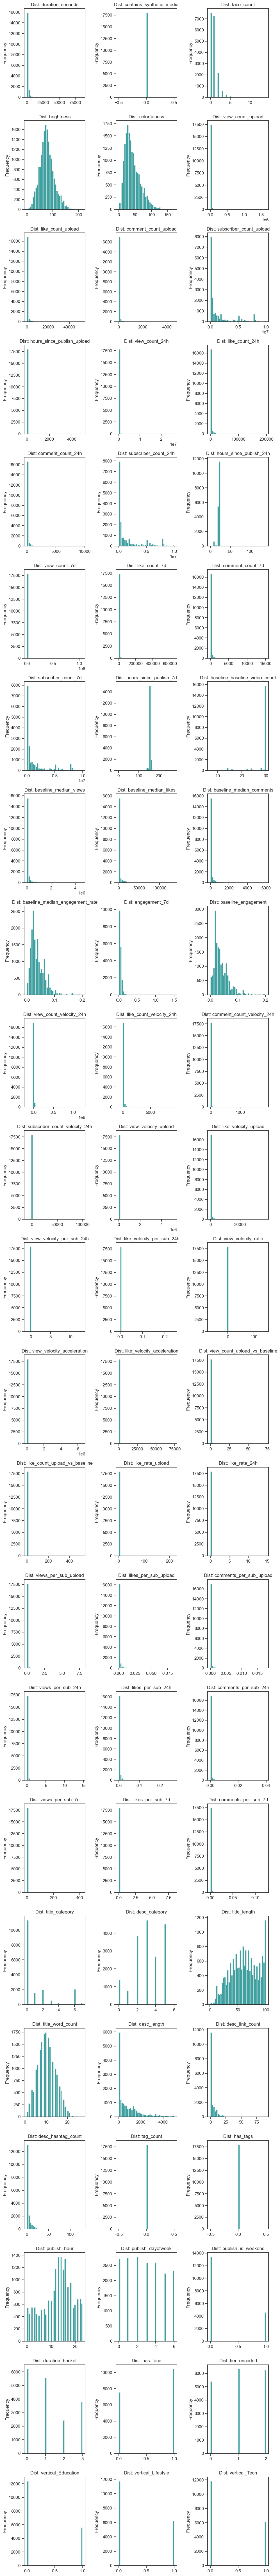

In [ ]:
eda.plot_engagement_distribution(run, save_figure_name="04_engineered_feature_distribution")

### Target Class Balance by Vertical & Tier

Mean `above_baseline` rate segmented by content vertical and channel tier. Because the target is defined relative to each channel's own historical median, the global rate is approximately 50% by construction — a video either beats its channel's median or it does not.

Deviations from 50% within a vertical/tier cell reveal structural effects:
- A vertical with a rate notably above 50% indicates that videos in that category are more likely to outperform their channel's median — possibly because the channel's baseline was set during a lower-engagement period.
- A tier with a rate notably below 50% may indicate that larger channels (higher tier) experience more volatile performance, making the baseline harder to beat consistently.

These structural differences are why the 18-cell stratification key (`vertical × tier × above_baseline`) is used when creating and maintaining the train/test/validation split.

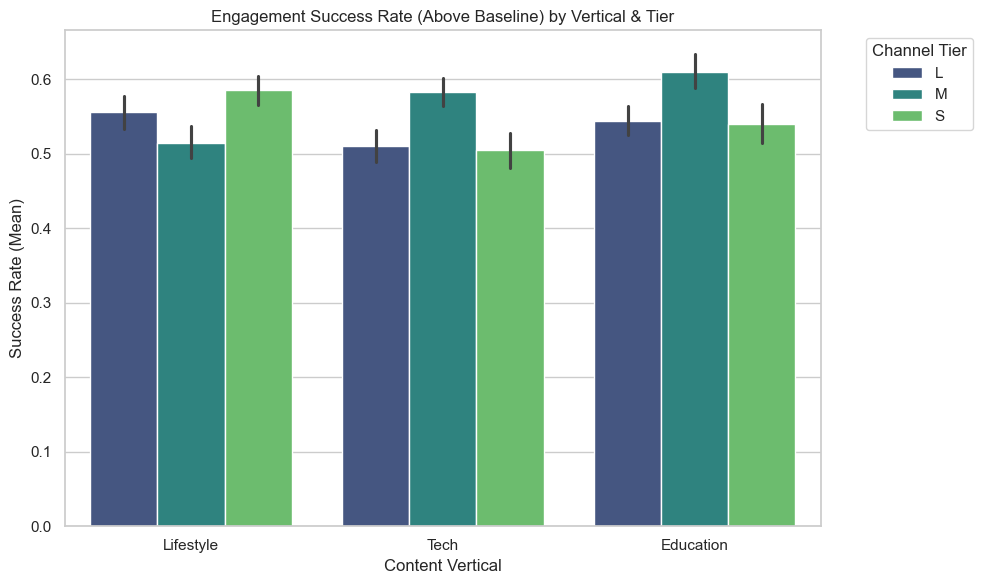

In [ ]:
eda.plot_label_rates(run, save_figure_name="05_target_class_balance_vertical_tier")

### Target Correlation & Leakage Check

Pearson correlation of every feature against `above_baseline`, sorted by absolute magnitude. This is the primary leakage check: a feature with |r| close to 1.0 would indicate it almost perfectly predicts the target, which typically means it was computed using information not available at upload time.

**What constitutes leakage in this context:** the target is defined at the 7-day mark (`view_count_7d > baseline`). Any feature that incorporates the 7-day view count directly — rather than just the upload-day or 24-hour count — would be leaky. The `view_ratio_7d_*` features are the ones to scrutinise most carefully here.

**Interpretation guide:** features with |r| > 0.5 should be examined to confirm they are computed from data available at the time of prediction (i.e., at or before the 24-hour mark). Features with |r| < 0.05 are likely noise and candidates for removal.

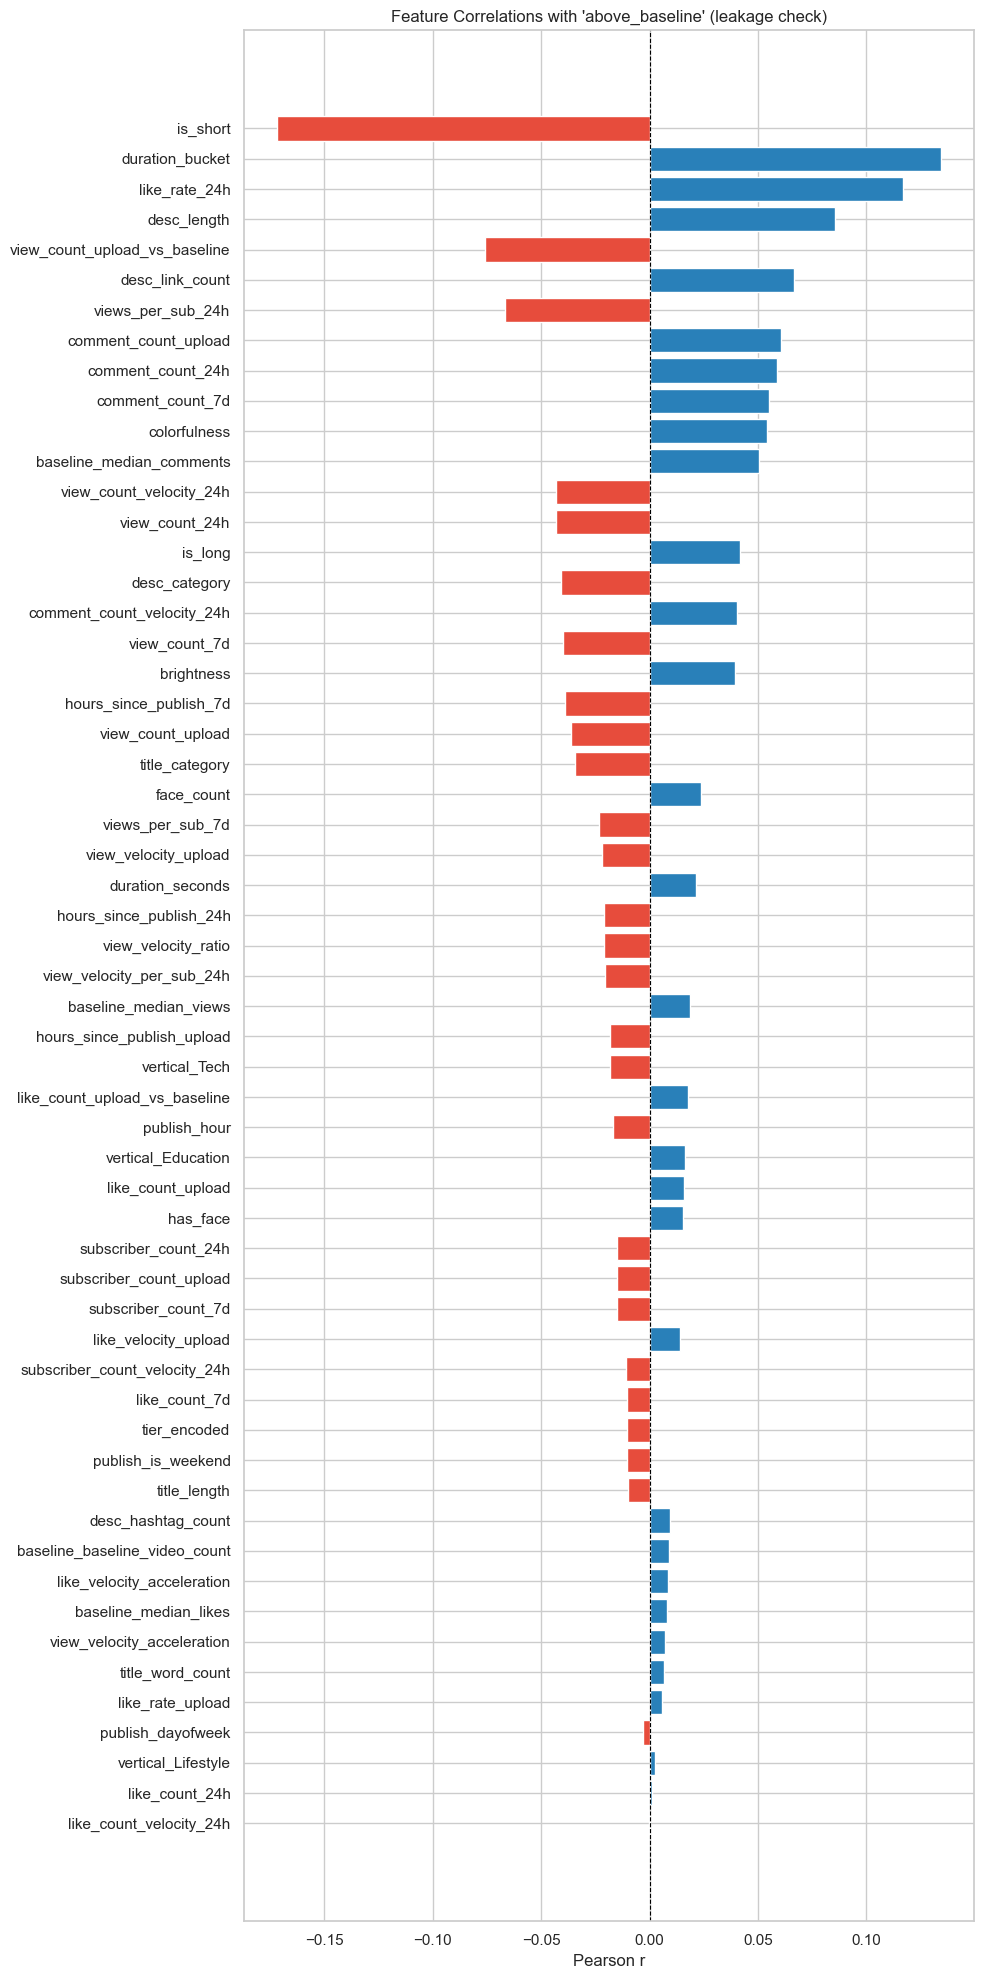

In [ ]:
eda.plot_target_correlations(run, save_figure_name="06_target_correlation")

### Full Feature Correlation Heatmap

Lower-triangle Pearson correlation matrix across all numeric features in `df_engineered`. Features with variance < 0.01 are filtered out before computing the matrix to keep the heatmap legible.

What to look for:
- **Inter-feature blocks of high |r|** — clusters of features that are nearly collinear with each other (e.g., all three raw view count columns, or all ratio features derived from the same base). These are candidates for regularisation (Ridge/Lasso already applied to the logistic regression model) or explicit removal if tree-based models overfit.
- **The `above_baseline` column/row** — should be consistent with the focused bar chart above; any feature showing very high |r| here is the same leakage concern.
- **Negative correlations** — a negative correlation between a feature and the target is not problematic in itself; it just means higher values of that feature are associated with lower-performing videos.

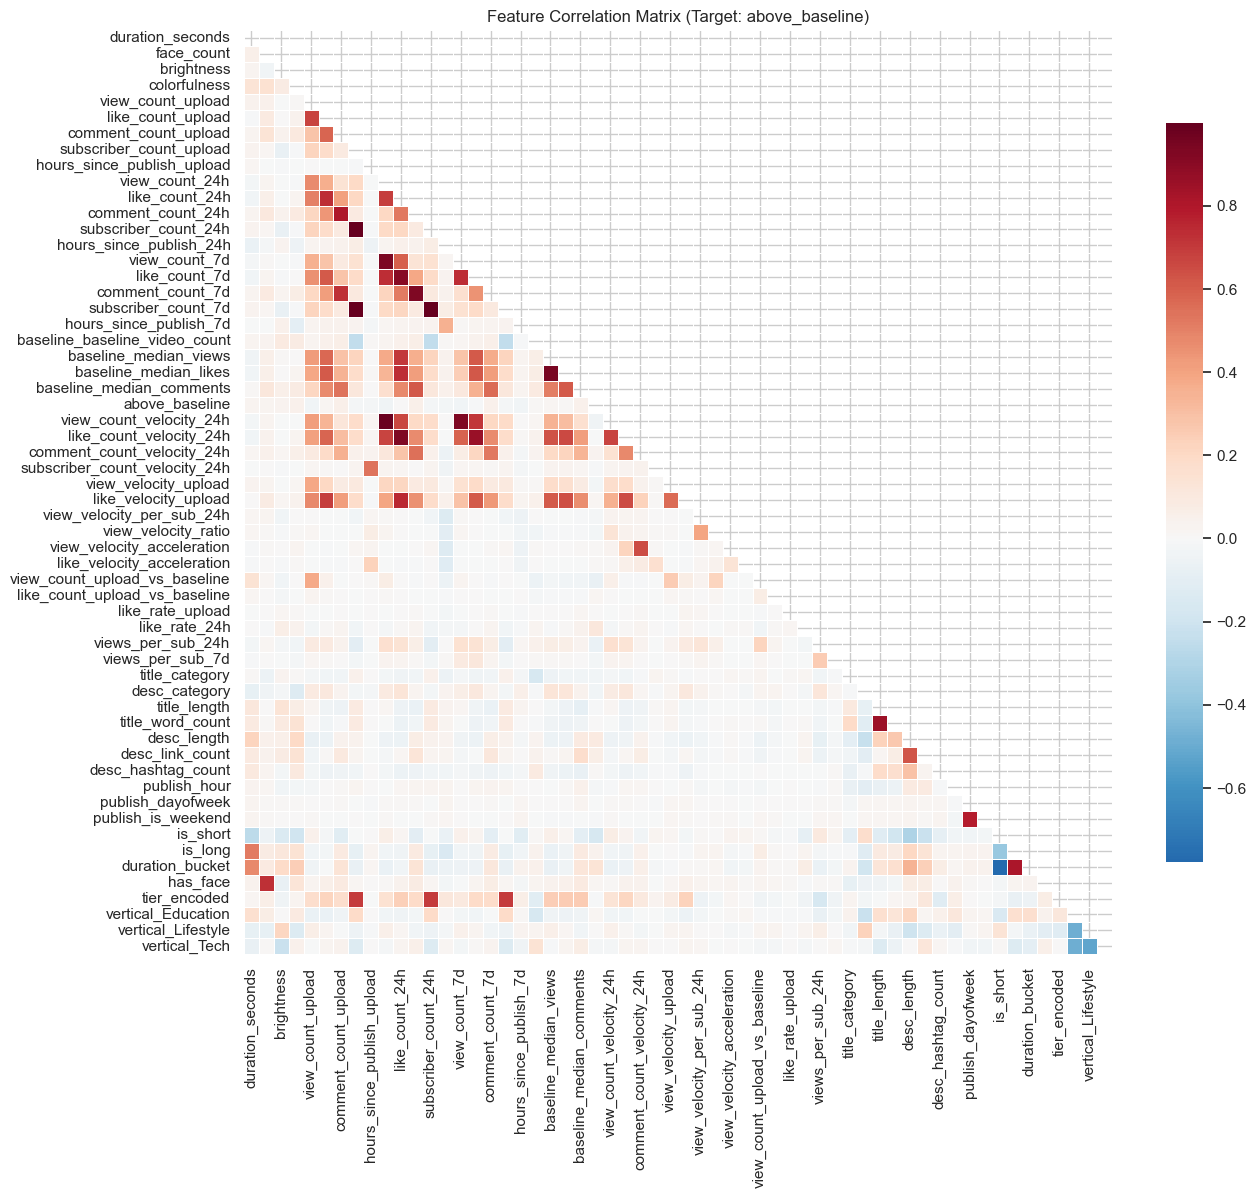

In [ ]:
eda.set_fig_size(run, 14, 12)
eda.plot_feature_correlations(run, save_figure_name="07_feature_correlation_headmap")